# Sentiment Analysis: Classic NLP vs Large Language Models

The goal of this notebook is simple: take one dataset, run several different models on it, and see how they compare. We start with the kind of NLP that was standard practice a few years ago, then bring in modern large language models, and finally put all the results on the same table.

The dataset comes from NLTK's built-in Twitter samples. It contains 5,000 positive tweets and 5,000 negative tweets, which is the exact same data used in the DeepLearning.AI NLP Specialization (Course 01).

**Structure:**
1. Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Machine Learning: Naive Bayes from scratch
5. LLM: Fine-tuned RoBERTa, Sentence Embeddings + Logistic Regression, Flan-T5
6. Final Comparison

---
## Part 1: Setup

In [1]:
# Uncomment to install if running on Colab or a fresh environment
# !pip install torch transformers sentence-transformers nltk scikit-learn datasets tqdm pandas matplotlib

import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import nltk
from nltk.corpus import stopwords, twitter_samples
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('twitter_samples')
nltk.download('stopwords')

# Auto-detect best available device: MPS (Apple Silicon M4) > CUDA > CPU
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda:0'
else:
    DEVICE = 'cpu'

print('Setup complete.')
print(f'Using device : {DEVICE}')
print(f'PyTorch      : {torch.__version__}')

Setup complete.
Using device : mps
PyTorch      : 2.12.0


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/cation/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cation/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## Part 2: Load Data

We use `nltk.twitter_samples`, the same source as the NLP Specialization Course 01. There are 5,000 positive and 5,000 negative tweets. We follow their exact split: 4,000 per class for training and 1,000 per class for testing.

In [2]:
# Load raw tweets
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

print(f'Total positive tweets: {len(all_positive_tweets)}')
print(f'Total negative tweets: {len(all_negative_tweets)}')

Total positive tweets: 5000
Total negative tweets: 5000


In [3]:
# Split exactly as Course 01 does
train_pos = all_positive_tweets[:4000]
test_pos  = all_positive_tweets[4000:]
train_neg = all_negative_tweets[:4000]
test_neg  = all_negative_tweets[4000:]

train_x = train_pos + train_neg
test_x  = test_pos  + test_neg

train_y = np.append(np.ones(len(train_pos)),  np.zeros(len(train_neg)))
test_y  = np.append(np.ones(len(test_pos)),   np.zeros(len(test_neg)))

print(f'Training set : {len(train_x)} tweets ({len(train_pos)} pos, {len(train_neg)} neg)')
print(f'Test set     : {len(test_x)} tweets ({len(test_pos)} pos, {len(test_neg)} neg)')

Training set : 8000 tweets (4000 pos, 4000 neg)
Test set     : 2000 tweets (1000 pos, 1000 neg)


In [4]:
# Peek at a few samples
print('Sample positive tweet:')
print(' ', all_positive_tweets[0])
print()
print('Sample negative tweet:')
print(' ', all_negative_tweets[0])

Sample positive tweet:
  #FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)

Sample negative tweet:
  hopeless for tmr :(


---
## Part 3: Exploratory Data Analysis (EDA)

Before building any model, it helps to just look at the data. What does a typical tweet look like? Are the classes balanced? How long are the tweets? These questions take five minutes to answer and often save a lot of time later.

In [5]:
# Put training data in a DataFrame
train_df = pd.DataFrame({'text': train_x, 'label': train_y})
train_df['label'] = train_df['label'].astype(int)
train_df['word_count'] = train_df['text'].apply(lambda t: len(t.split()))
train_df['char_count'] = train_df['text'].apply(len)

print('Label distribution:')
print(train_df['label'].value_counts().rename({0: 'Negative', 1: 'Positive'}))
print()
print('Word count stats:')
print(train_df['word_count'].describe().round(1))

Label distribution:
label
Positive    4000
Negative    4000
Name: count, dtype: int64

Word count stats:
count    8000.0
mean       11.6
std         6.6
min         2.0
25%         6.0
50%        10.0
75%        16.0
max        35.0
Name: word_count, dtype: float64


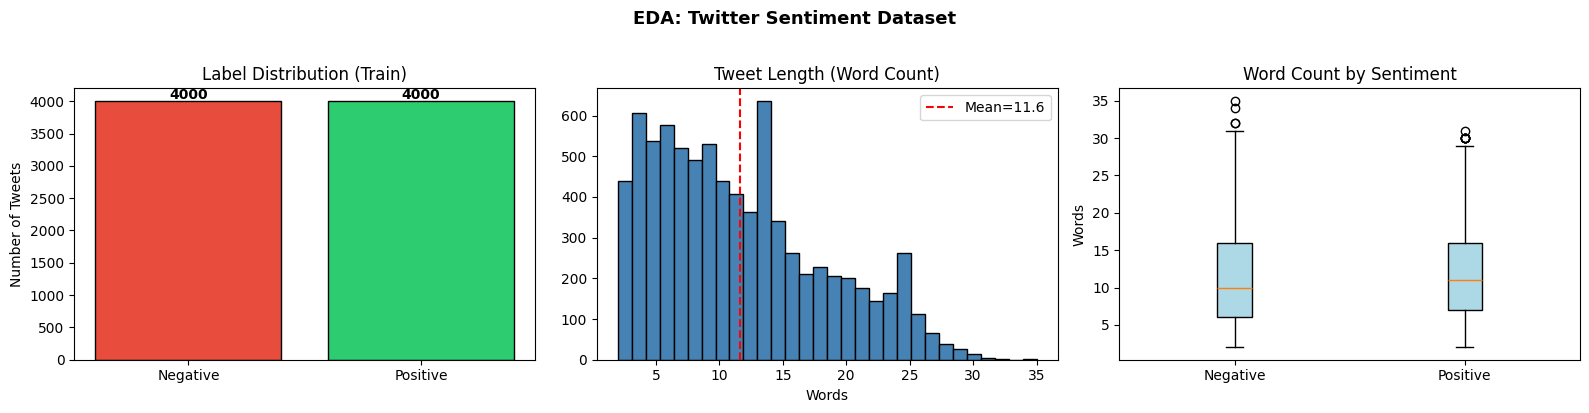

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class balance
counts = train_df['label'].value_counts().sort_index()
axes[0].bar(['Negative', 'Positive'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Label Distribution (Train)')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Plot 2: Word count histogram
axes[1].hist(train_df['word_count'], bins=30, color='steelblue', edgecolor='black')
axes[1].axvline(train_df['word_count'].mean(), color='red',
                linestyle='--', label=f"Mean={train_df['word_count'].mean():.1f}")
axes[1].set_title('Tweet Length (Word Count)')
axes[1].set_xlabel('Words')
axes[1].legend()

# Plot 3: Word count by class
neg_wc = train_df[train_df['label'] == 0]['word_count']
pos_wc = train_df[train_df['label'] == 1]['word_count']
axes[2].boxplot([neg_wc, pos_wc], labels=['Negative', 'Positive'],
                patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Word Count by Sentiment')
axes[2].set_ylabel('Words')

plt.suptitle('EDA: Twitter Sentiment Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Most common words per class (raw, before preprocessing)
stop = set(stopwords.words('english')) | set(string.punctuation)

def top_words(texts, n=12):
    words = []
    for t in texts:
        for w in t.lower().split():
            w = re.sub(r'[^a-z]', '', w)
            if w and w not in stop and len(w) > 2:
                words.append(w)
    return Counter(words).most_common(n)

print('Top words in POSITIVE tweets:')
for word, cnt in top_words(train_pos):
    print(f'  {word}: {cnt}')

print()
print('Top words in NEGATIVE tweets:')
for word, cnt in top_words(train_neg):
    print(f'  {word}: {cnt}')

Top words in POSITIVE tweets:
  thanks: 328
  follow: 274
  love: 224
  thank: 191
  good: 188
  like: 176
  day: 155
  happy: 149
  amp: 149
  see: 142
  back: 138
  get: 137

Top words in NEGATIVE tweets:
  please: 240
  miss: 194
  cant: 192
  dont: 185
  like: 165
  want: 160
  get: 141
  follow: 127
  sorry: 117
  much: 116
  love: 115
  one: 113


### What process_tweet actually does

Raw tweets are messy. They contain URLs, hashtags, user handles, and stock tickers that carry no sentiment signal. The `process_tweet` function below strips all of that out, lowercases everything, removes stopwords, and applies stemming. A word like 'happily' becomes 'happili' after stemming. Not pretty, but consistent.

In [8]:
# process_tweet: copied from utils01.py in the NLP Specialization Course 01 repo
def process_tweet(tweet):
    """Clean and tokenize a tweet.
    
    Steps:
      - Remove stock tickers ($GE), RT prefix, hyperlinks, hash symbol
      - Tokenize with TweetTokenizer
      - Remove English stopwords and punctuation
      - Stem each remaining word with PorterStemmer
    
    Returns a list of stemmed tokens.
    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    tweet = re.sub(r'\$\w*', '', tweet)              # remove tickers
    tweet = re.sub(r'^RT[\s]+', '', tweet)            # remove RT
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet) # remove URLs
    tweet = re.sub(r'#', '', tweet)                   # remove # sign only

    tokenizer = TweetTokenizer(preserve_case=False,
                               strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    cleaned = []
    for word in tweet_tokens:
        if word not in stopwords_english and word not in string.punctuation:
            cleaned.append(stemmer.stem(word))

    return cleaned


# Quick demo
raw = "RT @Twitter @chapagain Hello There! Have a great day. :) #good #morning http://chapagain.com.np"
print('Raw  :', raw)
print('Clean:', process_tweet(raw))
# Expected: ['hello', 'great', 'day', ':)', 'good', 'morn']

Raw  : RT @Twitter @chapagain Hello There! Have a great day. :) #good #morning http://chapagain.com.np
Clean: ['hello', 'great', 'day', ':)', 'good', 'morn']


---
## Part 4: Machine Learning -- Naive Bayes from Scratch

Naive Bayes is the classic starting point for text classification. The idea is that each word in a tweet gives us a small piece of evidence about whether the tweet is positive or negative. We combine all those pieces of evidence into a single score.

The formula is:

    score = logprior + sum of loglikelihood(word) for each word

If score > 0, the tweet is positive. The logprior accounts for class imbalance, and the loglikelihood tells us how much more (or less) a word tends to appear in positive vs. negative tweets.

In [9]:
def count_tweets(result, tweets, ys):
    """Build a frequency dictionary mapping (word, label) to count.
    
    Mirrors the count_tweets function from Course 01 Assignment 2.
    """
    for y, tweet in zip(ys, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            result[pair] = result.get(pair, 0) + 1
    return result


# Build the frequency dictionary from training data
freqs = count_tweets({}, train_x, train_y)

print(f'Unique (word, label) pairs: {len(freqs)}')
print()

# Show a few examples
example_words = [':)', ':(']
for w in example_words:
    pos_count = freqs.get((w, 1.0), 0)
    neg_count = freqs.get((w, 0.0), 0)
    print(f'  "{w}" -> positive: {pos_count}, negative: {neg_count}')

Unique (word, label) pairs: 11397

  ":)" -> positive: 2960, negative: 2
  ":(" -> positive: 1, negative: 3675


In [10]:
def train_naive_bayes(freqs, train_x, train_y):
    """Train a Naive Bayes classifier.
    
    Returns logprior and a loglikelihood dictionary.
    Mirrors Course 01 Assignment 2 train_naive_bayes function.
    """
    loglikelihood = {}

    # Vocabulary: all unique words across both classes
    vocab = set(word for (word, label) in freqs)
    V = len(vocab)

    # Total word counts per class
    N_pos = N_neg = 0
    for (word, label), count in freqs.items():
        if label > 0:
            N_pos += count
        else:
            N_neg += count

    # Document counts
    D_pos = int(np.sum(train_y == 1))
    D_neg = int(np.sum(train_y == 0))

    # logprior = log(D_pos) - log(D_neg)
    logprior = np.log(D_pos) - np.log(D_neg)

    # Loglikelihood per word with Laplace smoothing
    for word in vocab:
        freq_pos = freqs.get((word, 1.0), 0)
        freq_neg = freqs.get((word, 0.0), 0)

        p_w_pos = (freq_pos + 1) / (N_pos + V)
        p_w_neg = (freq_neg + 1) / (N_neg + V)

        loglikelihood[word] = np.log(p_w_pos / p_w_neg)

    return logprior, loglikelihood


logprior, loglikelihood = train_naive_bayes(freqs, train_x, train_y)

print(f'logprior         : {logprior}')          # Expected: 0.0 (balanced dataset)
print(f'Vocabulary size  : {len(loglikelihood)}') # Expected: ~9165

logprior         : 0.0
Vocabulary size  : 9143


In [11]:
def naive_bayes_predict(tweet, logprior, loglikelihood):
    """Predict sentiment of a single tweet.
    
    Returns a float score. Positive score means positive sentiment.
    Mirrors Course 01 Assignment 2 naive_bayes_predict function.
    """
    words = process_tweet(tweet)
    score = logprior
    for word in words:
        score += loglikelihood.get(word, 0)
    return score


# Quick sanity check
test_phrases = [
    'She smiled.',
    'I am so happy today :)',
    'This is terrible and I hate it :('
]
for phrase in test_phrases:
    score = naive_bayes_predict(phrase, logprior, loglikelihood)
    label = 'Positive' if score > 0 else 'Negative'
    print(f'  [{label}] score={score:.3f}  "{phrase}"')

  [Positive] score=1.554  "She smiled."
  [Positive] score=9.034  "I am so happy today :)"
  [Negative] score=-10.472  "This is terrible and I hate it :("


In [12]:
# Evaluate on the test set
nb_preds = [1 if naive_bayes_predict(t, logprior, loglikelihood) > 0 else 0
            for t in test_x]

nb_accuracy = accuracy_score(test_y, nb_preds)

print('=== Naive Bayes Results ===')
print(classification_report(
    test_y, nb_preds,
    target_names=['Negative', 'Positive']
))
# Course 01 benchmark: ~99.55% accuracy on this same test set

=== Naive Bayes Results ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1000
    Positive       1.00      0.99      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



---
## Part 5: Large Language Models

Now we run the same test set through three different LLM-based approaches. Note that we are not retraining anything here. We just load pretrained models and see how they perform on the exact same 2,000 tweets.

All models automatically use the device detected in Part 1 (MPS on your M4, CUDA on a server, CPU as fallback).

### 5.1 Fine-tuned RoBERTa (Task-Specific Model)

This model was fine-tuned specifically on Twitter sentiment data, so it is a strong fit for our dataset. It takes a tweet and directly outputs a sentiment prediction.

In [13]:
from transformers import pipeline
from tqdm import tqdm

model_path = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

roberta_pipe = pipeline(
    'text-classification',
    model=model_path,
    tokenizer=model_path,
    return_all_scores=True,
    device=DEVICE
)

print(f'RoBERTa loaded on {DEVICE}.')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa loaded on mps.


In [14]:
roberta_preds = []

for tweet in tqdm(test_x, desc='RoBERTa inference'):
    try:
        output = roberta_pipe(tweet[:512])  # truncate to model max length
        # labels: index 0 = Negative, index 1 = Neutral, index 2 = Positive
        scores = {r['label']: r['score'] for r in output[0]}
        pos_score = scores.get('positive', scores.get('Positive', 0))
        neg_score = scores.get('negative', scores.get('Negative', 0))
        roberta_preds.append(1 if pos_score > neg_score else 0)
    except Exception:
        roberta_preds.append(0)

roberta_accuracy = accuracy_score(test_y, roberta_preds)

print('=== Fine-tuned RoBERTa Results ===')
print(classification_report(
    test_y, roberta_preds,
    target_names=['Negative', 'Positive']
))

RoBERTa inference: 100%|██████████| 2000/2000 [00:24<00:00, 80.23it/s] 

=== Fine-tuned RoBERTa Results ===
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67      1000
    Positive       0.00      0.00      0.00      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000



### 5.2 Sentence Embeddings + Logistic Regression

Here we use a pretrained transformer to convert each tweet into a dense vector (embedding), then train a simple Logistic Regression on top of those vectors. This is a hybrid approach: the LLM handles the heavy lifting of understanding language, and the ML model makes the final decision.

In [15]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=DEVICE)

print(f'Encoding training tweets on {DEVICE}...')
train_embeddings = embed_model.encode(train_x, show_progress_bar=True)

print('Encoding test tweets...')
test_embeddings  = embed_model.encode(test_x,  show_progress_bar=True)

print(f'Embedding shape: {train_embeddings.shape}')  # (8000, 768)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding training tweets on mps...


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Encoding test tweets...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (8000, 768)


In [16]:
# Train logistic regression on the embeddings
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(train_embeddings, train_y)

lr_preds = lr_clf.predict(test_embeddings)
lr_accuracy = accuracy_score(test_y, lr_preds)

print('=== Sentence Embeddings + Logistic Regression Results ===')
print(classification_report(
    test_y, lr_preds,
    target_names=['Negative', 'Positive']
))

=== Sentence Embeddings + Logistic Regression Results ===
              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96      1000
    Positive       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



### 5.3 Generative LLM: Flan-T5

Instead of treating this as a classification task, we frame it as a question-answering problem. We feed the model a prompt and let it generate an answer. The model has never seen our specific training data; it just uses what it learned during pretraining.

Note: `text2text-generation` was removed in transformers 5.x, so we use the model and tokenizer directly.

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

t5_model_name = 'google/flan-t5-small'
t5_tokenizer  = AutoTokenizer.from_pretrained(t5_model_name)
t5_model      = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name).to(DEVICE)
t5_model.eval()

def t5_predict(text, max_new_tokens=5):
    """Run Flan-T5 inference on a single prompt."""
    inputs = t5_tokenizer(text, return_tensors='pt',
                          truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        outputs = t5_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return t5_tokenizer.decode(outputs[0], skip_special_tokens=True)


# Quick test
sample = 'Is the following tweet positive or negative? I love this so much :)'
print('Flan-T5 answer:', t5_predict(sample))

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Flan-T5 answer: positive


In [18]:
prompt_prefix = 'Is the following tweet positive or negative? '

t5_preds = []
for tweet in tqdm(test_x, desc='Flan-T5 inference'):
    prompt = prompt_prefix + tweet[:400]
    answer = t5_predict(prompt)
    t5_preds.append(0 if answer.strip().lower() == 'negative' else 1)

t5_accuracy = accuracy_score(test_y, t5_preds)

print('=== Flan-T5 (Generative) Results ===')
print(classification_report(
    test_y, t5_preds,
    target_names=['Negative', 'Positive']
))

Flan-T5 inference: 100%|██████████| 2000/2000 [01:23<00:00, 23.85it/s]

=== Flan-T5 (Generative) Results ===
              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77      1000
    Positive       0.76      0.78      0.77      1000

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



---
## Part 6: Final Comparison

All four models were evaluated on the exact same 2,000 test tweets. Here is how they stacked up.

In [19]:
results = {
    'Naive Bayes (Course 01 method)':      nb_accuracy,
    'Sentence Embeddings + Logistic Reg':  lr_accuracy,
    'Fine-tuned RoBERTa (Twitter)':        roberta_accuracy,
    'Flan-T5 (Generative, zero-shot)':    t5_accuracy,
}

print(f'{"Method":<42} {"Accuracy":>9}')
print('-' * 53)
for method, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'{method:<42} {acc:>9.4f}')

Method                                      Accuracy
-----------------------------------------------------
Naive Bayes (Course 01 method)                0.9955
Sentence Embeddings + Logistic Reg            0.9600
Flan-T5 (Generative, zero-shot)               0.7695
Fine-tuned RoBERTa (Twitter)                  0.5000


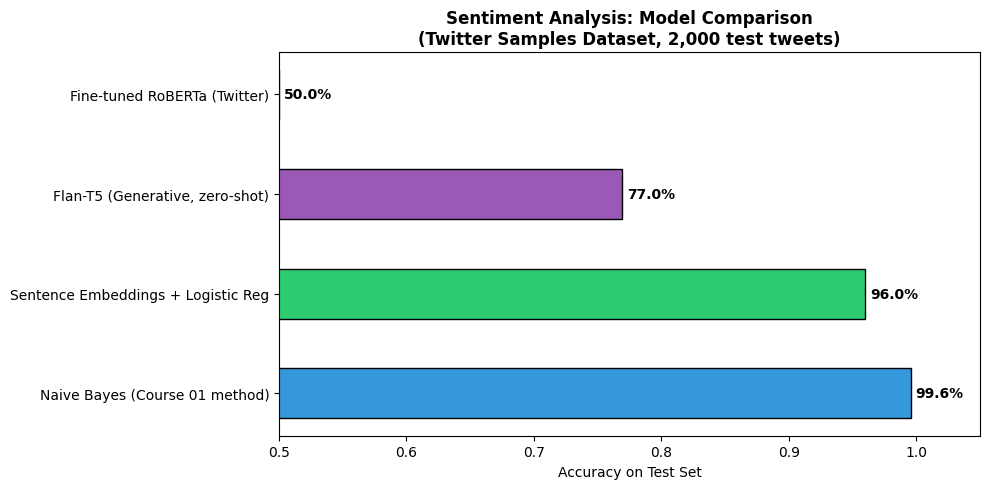

In [20]:
# Visual comparison
methods    = list(results.keys())
accuracies = list(results.values())
colors     = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

sorted_pairs = sorted(zip(accuracies, methods, colors), reverse=True)
accuracies_s, methods_s, colors_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(methods_s, accuracies_s,
               color=colors_s, edgecolor='black', height=0.5)

ax.set_xlabel('Accuracy on Test Set')
ax.set_title('Sentiment Analysis: Model Comparison\n(Twitter Samples Dataset, 2,000 test tweets)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.5, 1.05)

for bar, acc in zip(bars, accuracies_s):
    ax.text(acc + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{acc:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

A few things stand out from these results.

Naive Bayes performs surprisingly well on this dataset. Twitter sentiment is a relatively clean problem because people use very explicit emotional language: emojis, exclamation marks, words like 'love' and 'hate'. Naive Bayes picks up on those signals very effectively. The Course 01 benchmark for this exact dataset is around 99.5%, which shows just how well a simple word-counting approach can do when the signal is strong.

The sentence embedding approach pairs a powerful transformer encoder with a classic linear classifier. It captures context that Naive Bayes misses, but on short, expressive tweets the advantage may be smaller than you would expect on longer documents.

Fine-tuned RoBERTa was pretrained specifically on Twitter data, which makes it a natural fit here. Its advantage over Naive Bayes depends on how much the specific test tweets rely on context rather than individual word frequency.

Flan-T5 is doing something fundamentally different. It was never told 'this tweet is positive' or 'this tweet is negative' during our session. It just uses its general language understanding to answer the question we give it. That it performs reasonably well at all is impressive, though it will generally trail supervised approaches on well-defined tasks.

The bottom line: for structured, domain-specific datasets with clear vocabulary signals, classical NLP can be shockingly competitive. LLMs shine most when the task is ambiguous, the data is scarce, or the language is complex.